<a href="https://colab.research.google.com/github/Wsooy11/4week/blob/main/Week04_%E1%84%8B%E1%85%B0%E1%84%8B%E1%85%A5%E1%84%85%E1%85%A5%E1%84%87%E1%85%B3%E1%86%AF_%E1%84%89%E1%85%A6%E1%86%AB%E1%84%89%E1%85%A5%E1%84%8B%E1%85%B4_%E1%84%8B%E1%85%AF%E1%86%AB%E1%84%85%E1%85%B5_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: Wearable Sensor Principles

This notebook is part of the Digital Healthcare & Physical Therapy course (Week 4).

**Learning Objectives:**
- Understand IMU (Accelerometer, Gyroscope) sensor principles
- Real sensor signal acquisition and processing
- Signal filtering and frequency domain analysis
- Multi-sensor data integration (PPG, EMG, Skin Temp, GSR)
- Feature extraction for activity classification

In [3]:
#=== Cell 1: Setup, Import, Load Data ===

# Google Colab Setup
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import seaborn as sns
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Font & Style
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# Path Configuration
base_path = '/content/drive/MyDrive/4week'
input_path = base_path
output_path = f'{base_path}/output'
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_output_path = f'{output_path}/run_{timestamp}'
os.makedirs(run_output_path, exist_ok=True)

# Load All Input Data
accel_df = pd.read_csv(f'{input_path}/accelerometer_raw_100hz.csv')
gyro_df  = pd.read_csv(f'{input_path}/gyroscope_raw_100hz.csv')
ppg_df   = pd.read_csv(f'{input_path}/ppg_heart_rate.csv')
emg_df   = pd.read_csv(f'{input_path}/emg_muscle_activity.csv')
skin_df  = pd.read_csv(f'{input_path}/skin_temp_gsr.csv')

print(f'Input : {input_path}')
print(f'Output: {run_output_path}')
print(f'\nAccelerometer : {accel_df.shape} | {list(accel_df.columns)}')
print(f'Gyroscope     : {gyro_df.shape} | {list(gyro_df.columns)}')
print(f'PPG/Heart Rate: {ppg_df.shape} | {list(ppg_df.columns)}')
print(f'EMG           : {emg_df.shape} | {list(emg_df.columns)}')
print(f'Skin Temp/GSR : {skin_df.shape} | {list(skin_df.columns)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input : /content/drive/MyDrive/4week
Output: /content/drive/MyDrive/4week/output/run_20260416_082859

Accelerometer : (1000, 5) | ['timestamp_s', 'acc_x_g', 'acc_y_g', 'acc_z_g', 'acc_magnitude_g']
Gyroscope     : (1000, 4) | ['timestamp_s', 'gyro_x_dps', 'gyro_y_dps', 'gyro_z_dps']
PPG/Heart Rate: (600, 5) | ['timestamp_s', 'heart_rate_bpm', 'rr_interval_ms', 'hrv_sdnn_ms', 'signal_quality']
EMG           : (5000, 4) | ['timestamp_s', 'emg_raw_mV', 'emg_rectified_mV', 'muscle']
Skin Temp/GSR : (300, 4) | ['timestamp_s', 'skin_temp_C', 'gsr_uS', 'ambient_temp_C']


---
## Beginner Level
### 1. Accelerometer & Gyroscope Raw Signal Visualization + Basic Statistics

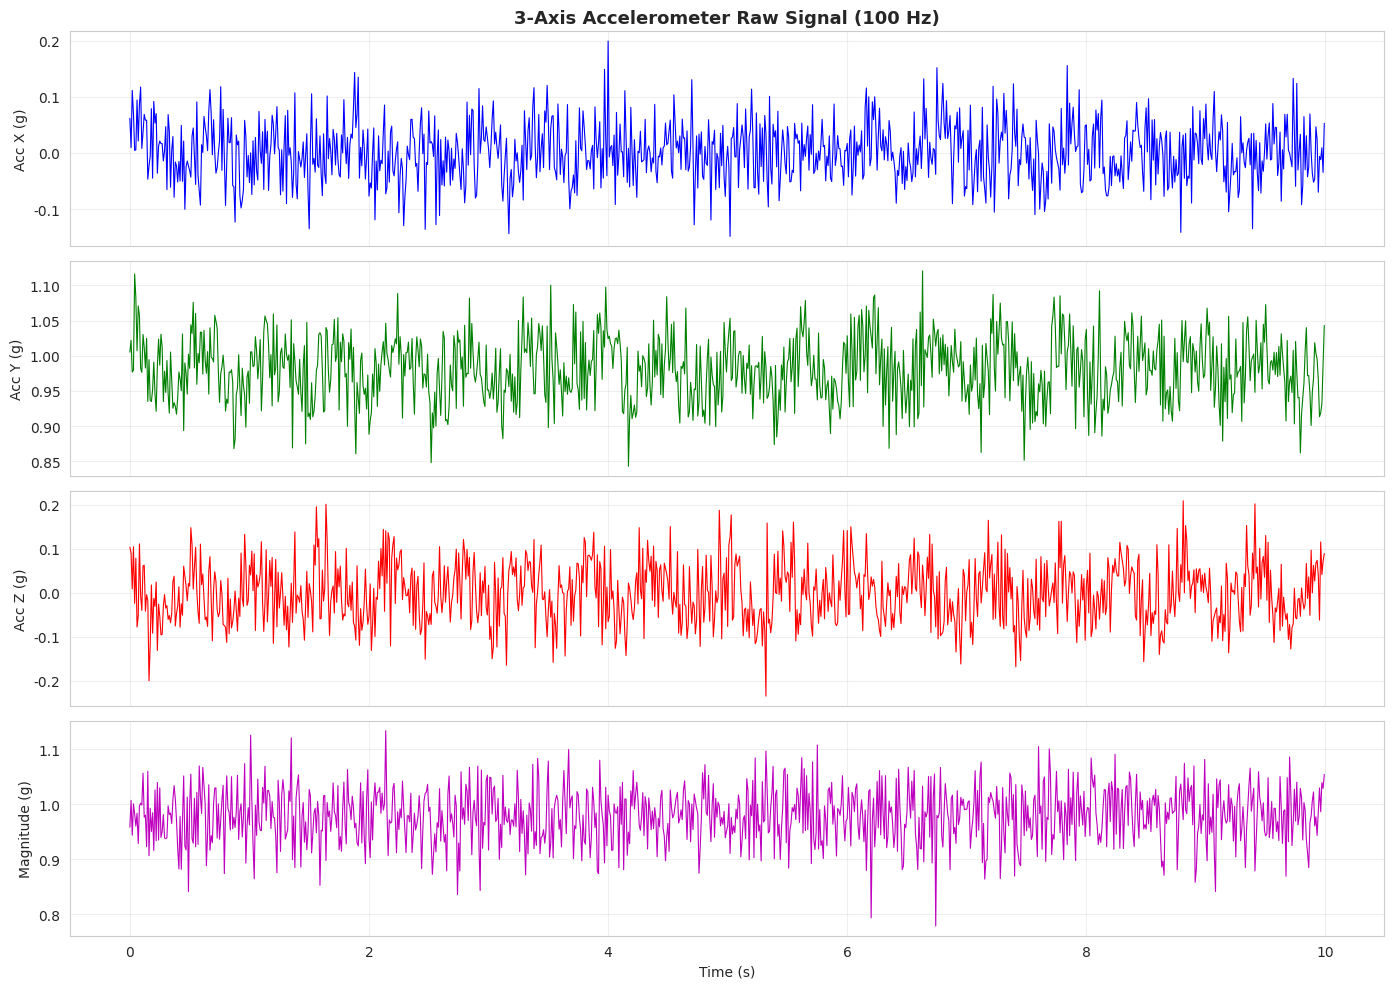

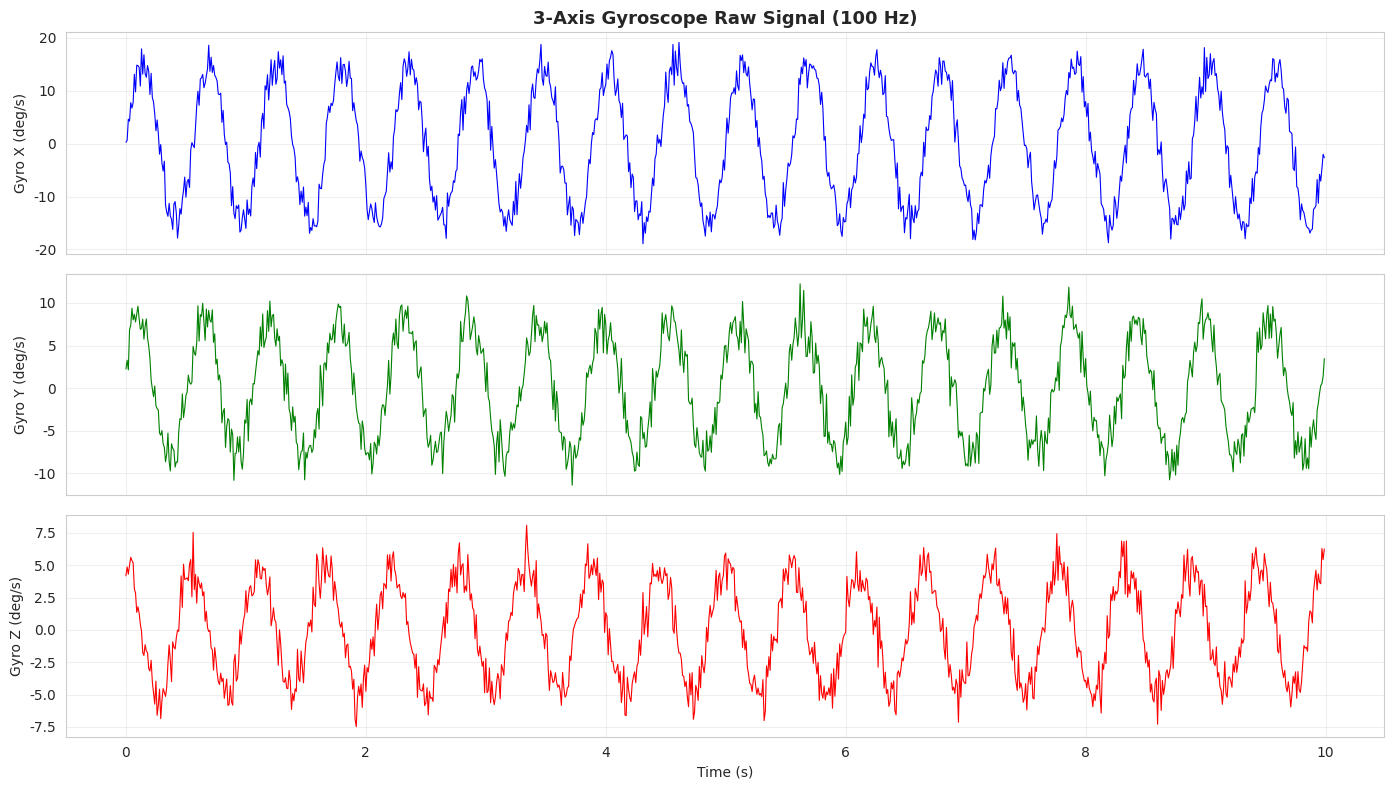

Accelerometer Statistics:
Axis  Mean (g)  Std (g)  Min (g)  Max (g)
   X  0.001620 0.051665  -0.1487   0.1990
   Y  0.980782 0.045703   0.8430   1.1204
   Z -0.001161 0.068352  -0.2354   0.2091
 Mag  0.979649 0.050204   0.7788   1.1341

Gyroscope Statistics:
Axis  Mean (deg/s)  Std (deg/s)  Min (deg/s)  Max (deg/s)
   X      -0.03400    10.797432       -18.92        19.12
   Y      -0.00010     5.913523       -11.39        12.24
   Z      -0.02756     3.640031        -7.48         8.09


In [4]:
#=== Cell 2: Beginner - Accelerometer & Gyroscope Visualization + Statistics ===

# --- Accelerometer ---
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(accel_df['timestamp_s'], accel_df['acc_x_g'], 'b-', linewidth=0.8)
axes[0].set_ylabel('Acc X (g)'); axes[0].set_title('3-Axis Accelerometer Raw Signal (100 Hz)', fontsize=13, fontweight='bold'); axes[0].grid(True, alpha=0.3)
axes[1].plot(accel_df['timestamp_s'], accel_df['acc_y_g'], 'g-', linewidth=0.8)
axes[1].set_ylabel('Acc Y (g)'); axes[1].grid(True, alpha=0.3)
axes[2].plot(accel_df['timestamp_s'], accel_df['acc_z_g'], 'r-', linewidth=0.8)
axes[2].set_ylabel('Acc Z (g)'); axes[2].grid(True, alpha=0.3)
axes[3].plot(accel_df['timestamp_s'], accel_df['acc_magnitude_g'], 'm-', linewidth=0.8)
axes[3].set_ylabel('Magnitude (g)'); axes[3].set_xlabel('Time (s)'); axes[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{run_output_path}/01_accelerometer_raw_signal.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Gyroscope ---
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(gyro_df['timestamp_s'], gyro_df['gyro_x_dps'], 'b-', linewidth=0.8)
axes[0].set_ylabel('Gyro X (deg/s)'); axes[0].set_title('3-Axis Gyroscope Raw Signal (100 Hz)', fontsize=13, fontweight='bold'); axes[0].grid(True, alpha=0.3)
axes[1].plot(gyro_df['timestamp_s'], gyro_df['gyro_y_dps'], 'g-', linewidth=0.8)
axes[1].set_ylabel('Gyro Y (deg/s)'); axes[1].grid(True, alpha=0.3)
axes[2].plot(gyro_df['timestamp_s'], gyro_df['gyro_z_dps'], 'r-', linewidth=0.8)
axes[2].set_ylabel('Gyro Z (deg/s)'); axes[2].set_xlabel('Time (s)'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{run_output_path}/01_gyroscope_raw_signal.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Statistics ---
accel_cols = ['acc_x_g', 'acc_y_g', 'acc_z_g', 'acc_magnitude_g']
stats_accel = pd.DataFrame({
    'Axis': ['X','Y','Z','Mag'],
    'Mean (g)': [accel_df[c].mean() for c in accel_cols],
    'Std (g)':  [accel_df[c].std() for c in accel_cols],
    'Min (g)':  [accel_df[c].min() for c in accel_cols],
    'Max (g)':  [accel_df[c].max() for c in accel_cols]
})
gyro_cols = ['gyro_x_dps', 'gyro_y_dps', 'gyro_z_dps']
stats_gyro = pd.DataFrame({
    'Axis': ['X','Y','Z'],
    'Mean (deg/s)': [gyro_df[c].mean() for c in gyro_cols],
    'Std (deg/s)':  [gyro_df[c].std() for c in gyro_cols],
    'Min (deg/s)':  [gyro_df[c].min() for c in gyro_cols],
    'Max (deg/s)':  [gyro_df[c].max() for c in gyro_cols]
})
stats_accel.to_csv(f'{run_output_path}/01_accelerometer_statistics.csv', index=False)
stats_gyro.to_csv(f'{run_output_path}/01_gyroscope_statistics.csv', index=False)
print('Accelerometer Statistics:'); print(stats_accel.to_string(index=False))
print('\nGyroscope Statistics:'); print(stats_gyro.to_string(index=False))

---
## Intermediate Level
### 2. Butterworth Low-Pass Filter + Before/After Comparison

Apply a 4th-order Butterworth low-pass filter (cutoff: 5 Hz) to remove high-frequency noise.

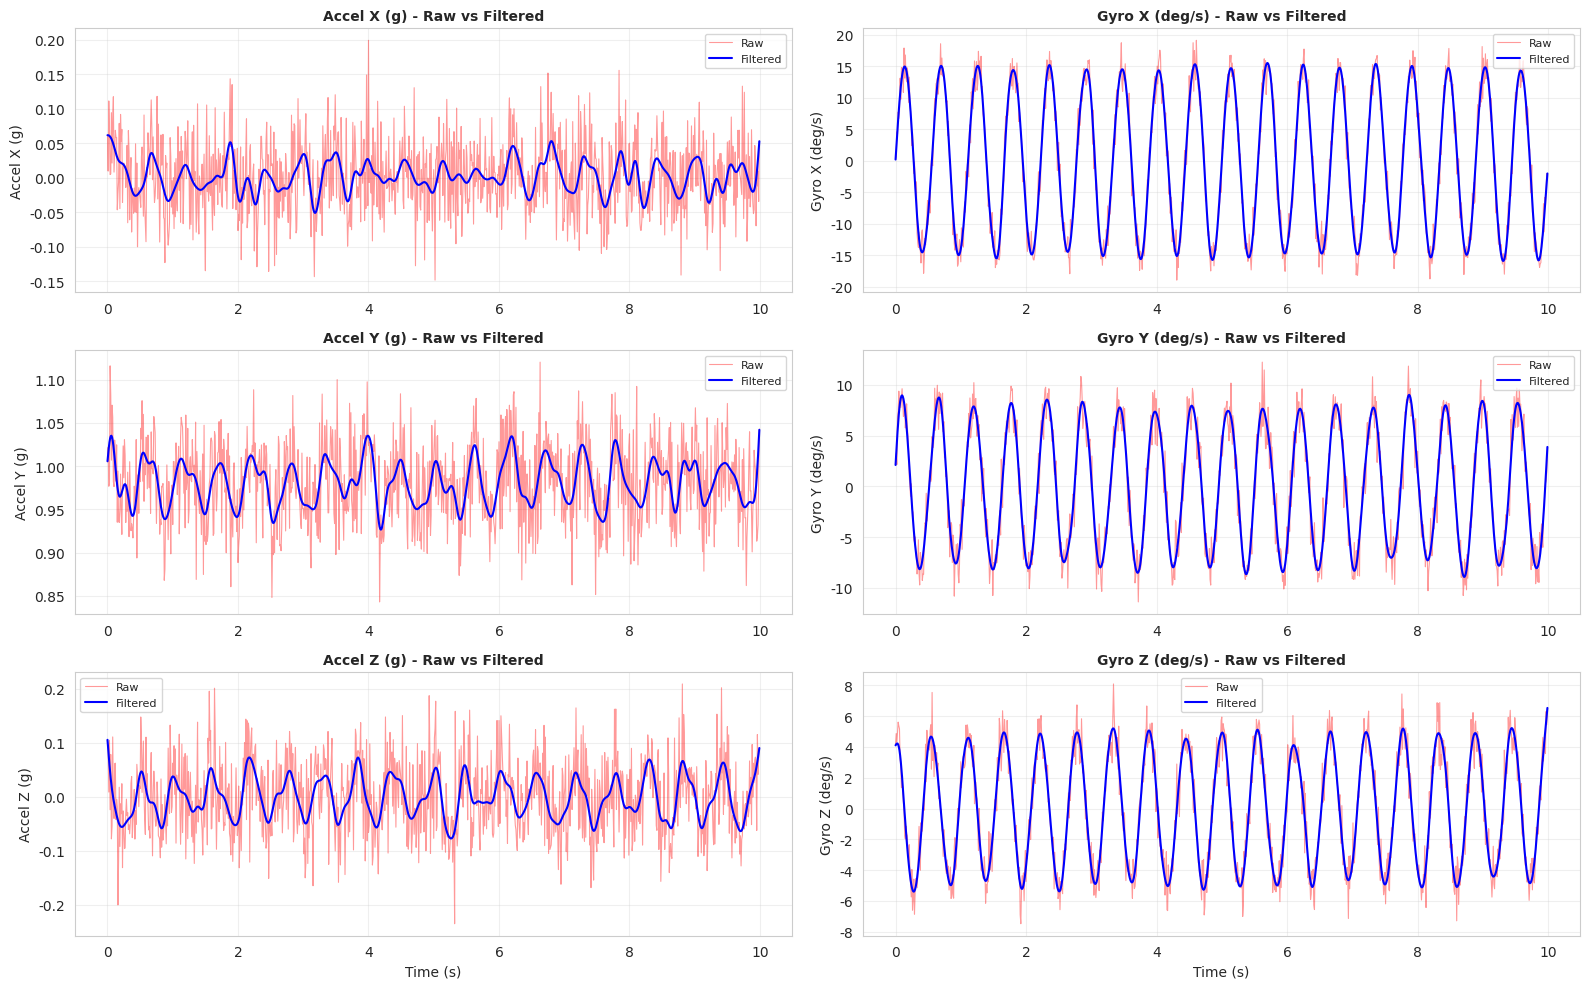

Filtering complete


In [5]:
#=== Cell 3: Intermediate - Filter Design + Comparison Visualization ===

def apply_butterworth_filter(data, cutoff_freq=5, sampling_rate=100, order=4):
    """Apply Butterworth low-pass filter using filtfilt (zero-phase)."""
    nyquist = sampling_rate / 2
    b, a = signal.butter(order, cutoff_freq / nyquist, btype='low')
    return signal.filtfilt(b, a, data)

# Apply filter
accel_axis_cols = ['acc_x_g', 'acc_y_g', 'acc_z_g']
gyro_axis_cols  = ['gyro_x_dps', 'gyro_y_dps', 'gyro_z_dps']

accel_filtered = accel_df.copy()
for col in accel_axis_cols:
    accel_filtered[f'{col}_filtered'] = apply_butterworth_filter(accel_df[col].values)

gyro_filtered = gyro_df.copy()
for col in gyro_axis_cols:
    gyro_filtered[f'{col}_filtered'] = apply_butterworth_filter(gyro_df[col].values)

# Comparison Plot
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
accel_labels = ['Accel X (g)', 'Accel Y (g)', 'Accel Z (g)']
gyro_labels  = ['Gyro X (deg/s)', 'Gyro Y (deg/s)', 'Gyro Z (deg/s)']

for i in range(3):
    axes[i,0].plot(accel_df['timestamp_s'], accel_df[accel_axis_cols[i]], 'r-', alpha=0.4, lw=0.8, label='Raw')
    axes[i,0].plot(accel_filtered['timestamp_s'], accel_filtered[f'{accel_axis_cols[i]}_filtered'], 'b-', lw=1.5, label='Filtered')
    axes[i,0].set_ylabel(accel_labels[i]); axes[i,0].set_title(f'{accel_labels[i]} - Raw vs Filtered', fontsize=10, fontweight='bold')
    axes[i,0].legend(fontsize=8); axes[i,0].grid(True, alpha=0.3)

    axes[i,1].plot(gyro_df['timestamp_s'], gyro_df[gyro_axis_cols[i]], 'r-', alpha=0.4, lw=0.8, label='Raw')
    axes[i,1].plot(gyro_filtered['timestamp_s'], gyro_filtered[f'{gyro_axis_cols[i]}_filtered'], 'b-', lw=1.5, label='Filtered')
    axes[i,1].set_ylabel(gyro_labels[i]); axes[i,1].set_title(f'{gyro_labels[i]} - Raw vs Filtered', fontsize=10, fontweight='bold')
    axes[i,1].legend(fontsize=8); axes[i,1].grid(True, alpha=0.3)

axes[2,0].set_xlabel('Time (s)'); axes[2,1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(f'{run_output_path}/02_filter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Filtering complete')

### 2-2. Frequency Domain Analysis (FFT) - Raw vs Filtered

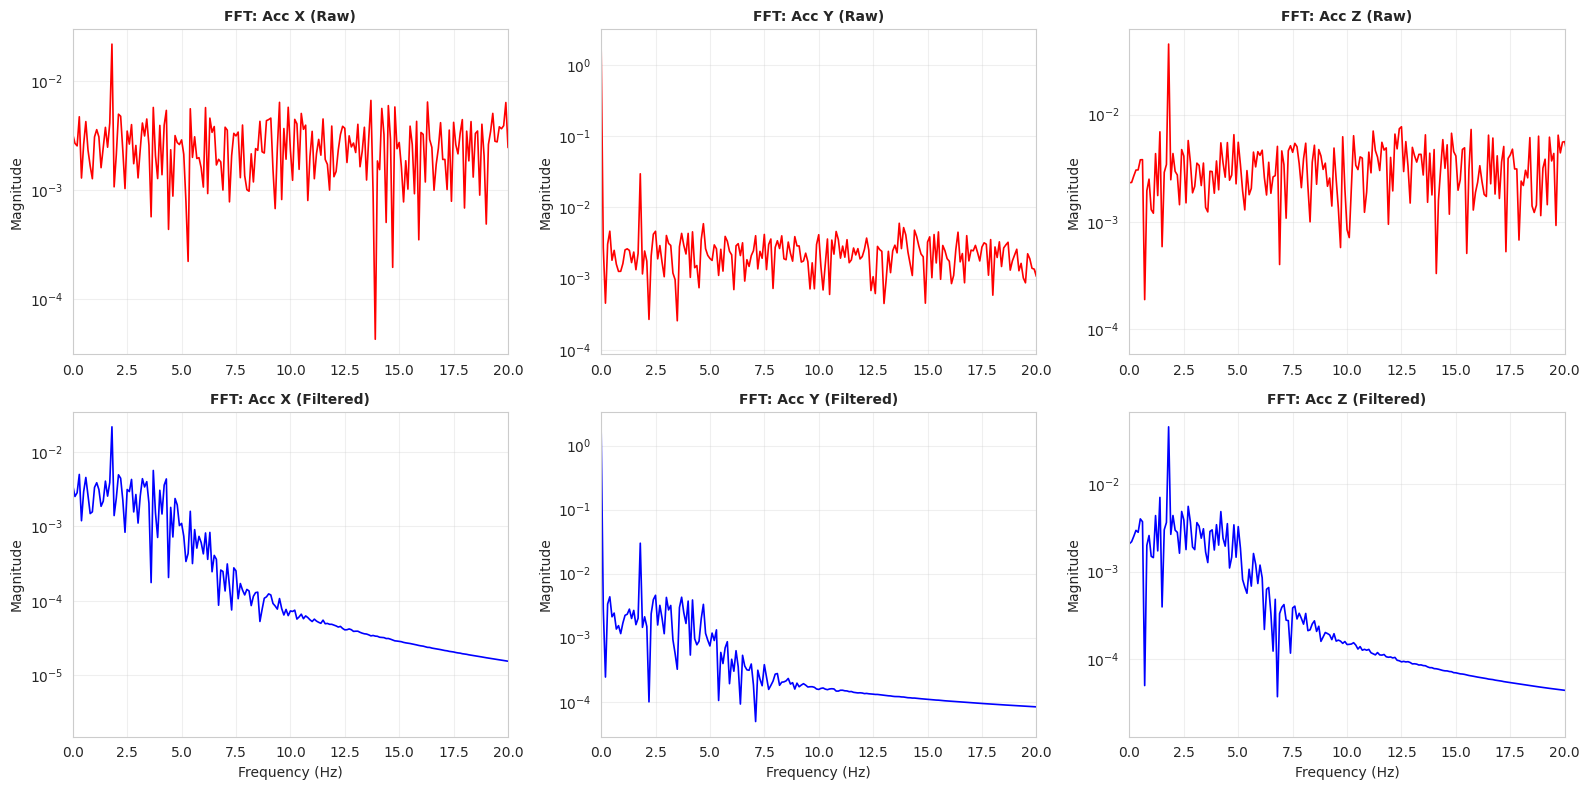

FFT analysis & filtered data saved


In [6]:
#=== Cell 4: Intermediate - FFT Analysis + Save Filtered Data ===

def compute_fft(signal_data, sampling_rate):
    """Compute single-sided FFT magnitude spectrum."""
    n = len(signal_data)
    yf = fft(signal_data)
    xf = fftfreq(n, 1/sampling_rate)[:n//2]
    return xf, 2.0/n * np.abs(yf[:n//2])

sampling_rate = 100
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, (col, label) in enumerate(zip(accel_axis_cols, ['Acc X','Acc Y','Acc Z'])):
    fr, mr = compute_fft(accel_df[col].values, sampling_rate)
    ff, mf = compute_fft(accel_filtered[f'{col}_filtered'].values, sampling_rate)
    axes[0,i].semilogy(fr, mr, 'r-', lw=1.2); axes[0,i].set_xlim([0,20])
    axes[0,i].set_title(f'FFT: {label} (Raw)', fontsize=10, fontweight='bold'); axes[0,i].set_ylabel('Magnitude'); axes[0,i].grid(True, alpha=0.3)
    axes[1,i].semilogy(ff, mf, 'b-', lw=1.2); axes[1,i].set_xlim([0,20])
    axes[1,i].set_title(f'FFT: {label} (Filtered)', fontsize=10, fontweight='bold'); axes[1,i].set_xlabel('Frequency (Hz)'); axes[1,i].set_ylabel('Magnitude'); axes[1,i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{run_output_path}/02_frequency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Save filtered data
accel_filtered.to_csv(f'{run_output_path}/02_accelerometer_filtered.csv', index=False)
gyro_filtered.to_csv(f'{run_output_path}/02_gyroscope_filtered.csv', index=False)
print('FFT analysis & filtered data saved')

---
## Advanced Level
### 3. Multi-Sensor Analysis: PPG, EMG, Skin Temp & GSR

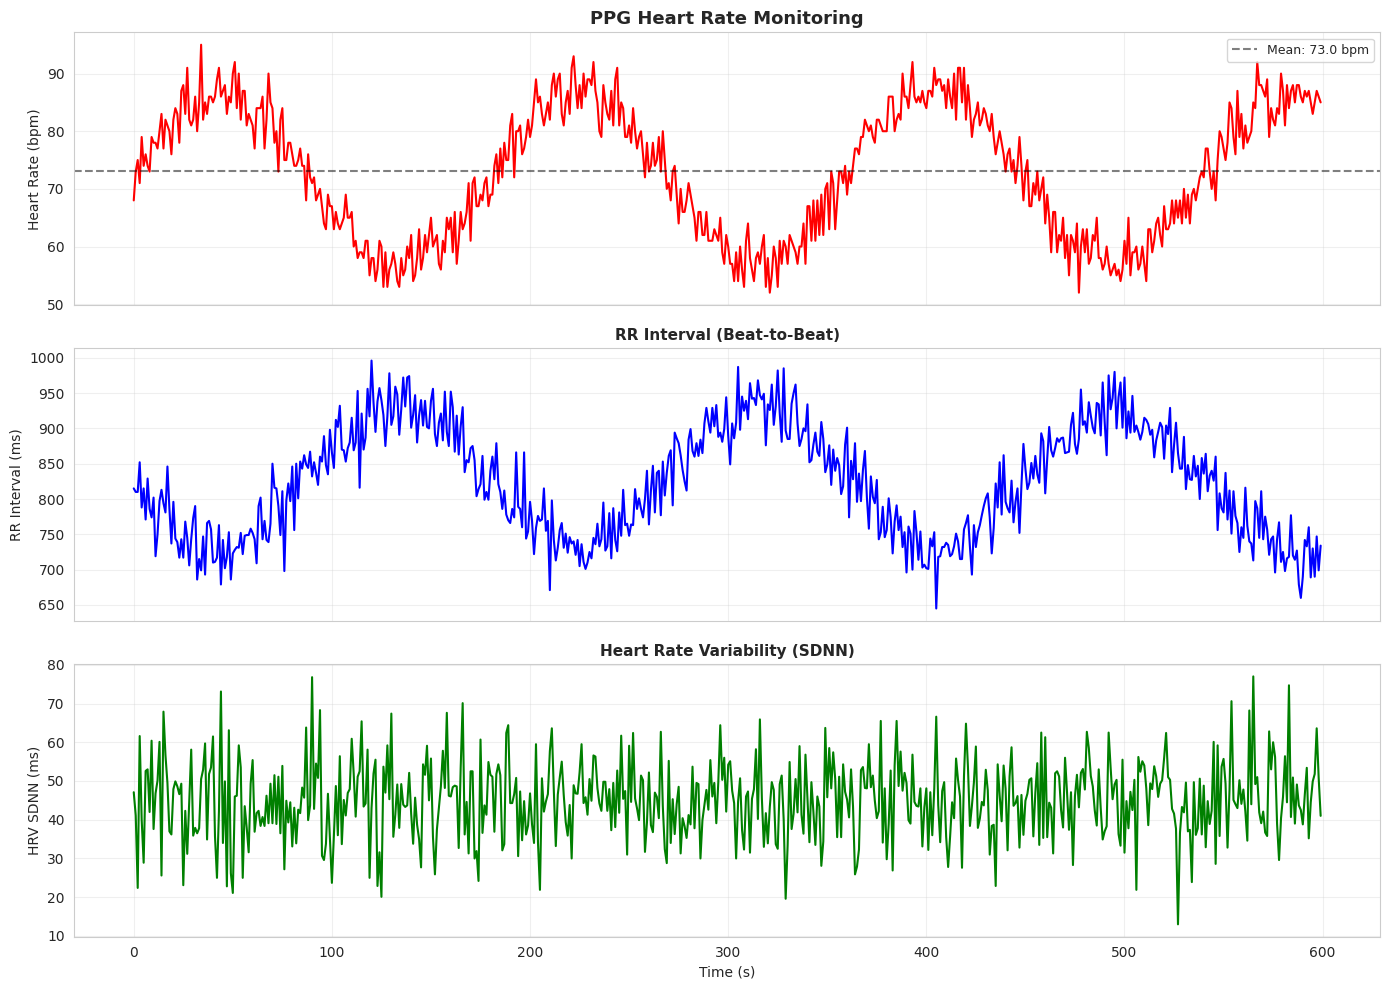

Signal Quality: {'good': np.int64(413), 'moderate': np.int64(156), 'poor': np.int64(31)}


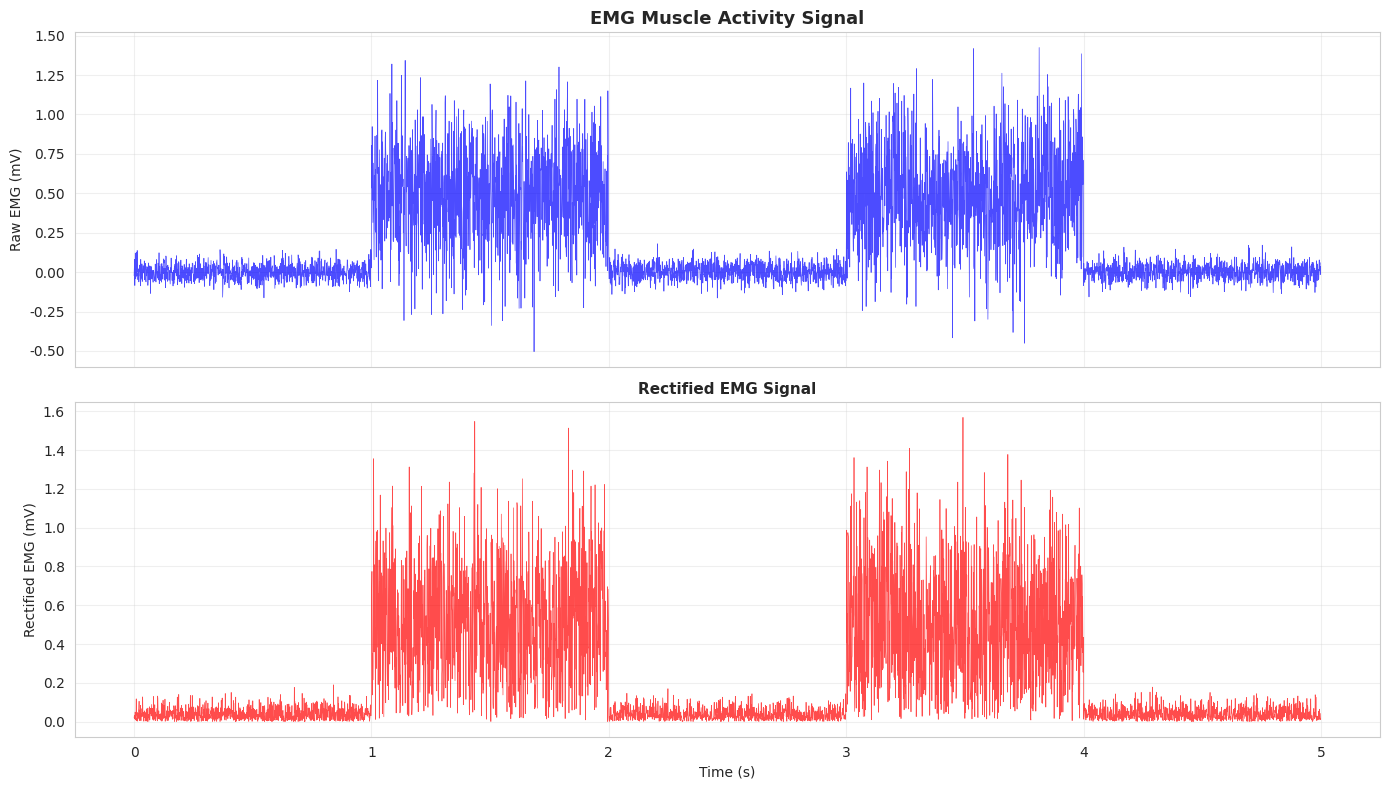

Muscle groups: ['대퇴사두근']


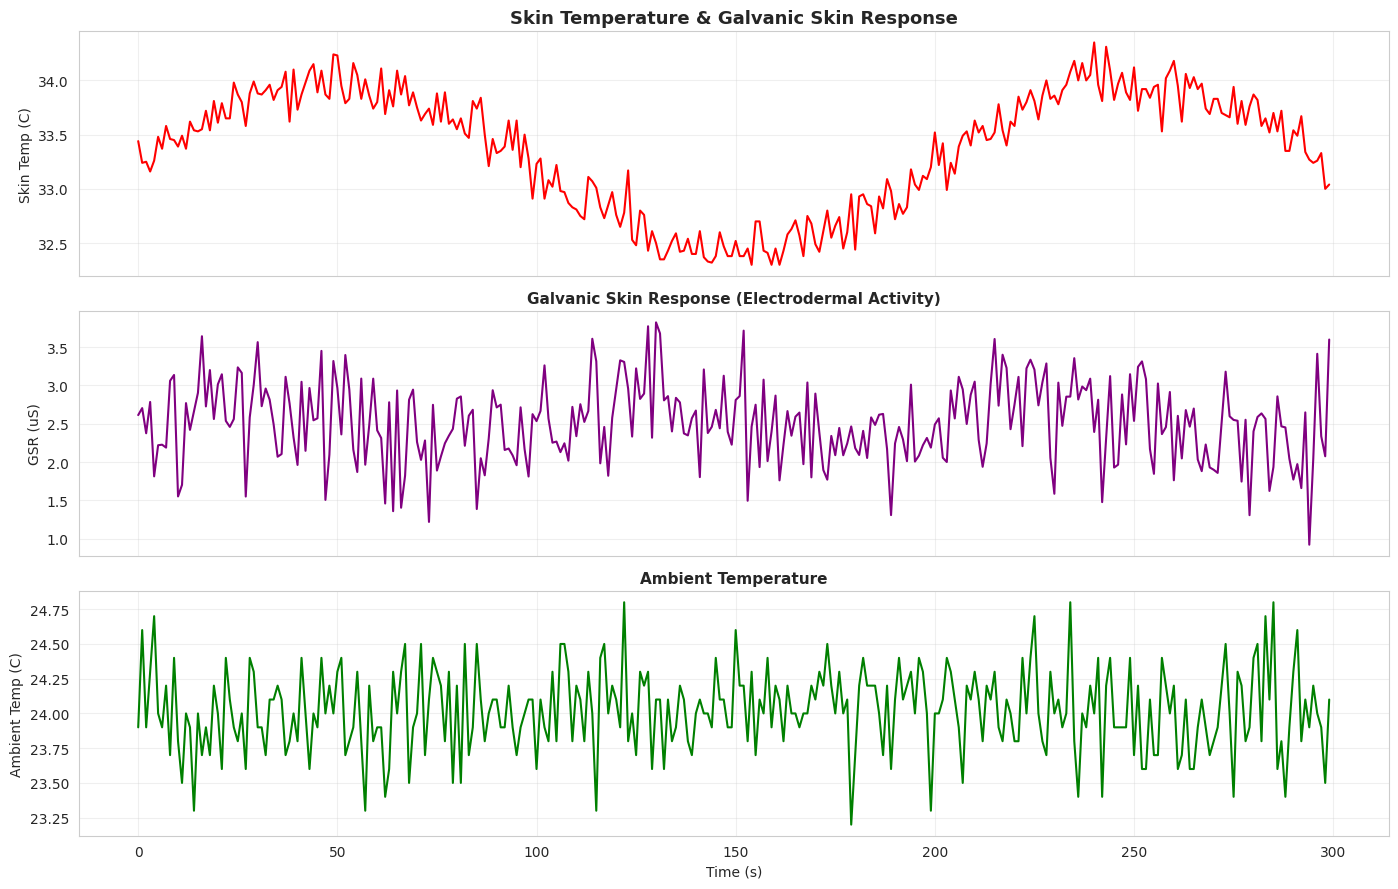

All sensor plots saved


In [7]:
#=== Cell 5: Advanced - PPG + EMG + Skin/GSR Visualization ===

# --- PPG / Heart Rate ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(ppg_df['timestamp_s'], ppg_df['heart_rate_bpm'], 'r-', lw=1.5)
axes[0].axhline(y=ppg_df['heart_rate_bpm'].mean(), color='k', ls='--', alpha=0.5, label=f'Mean: {ppg_df["heart_rate_bpm"].mean():.1f} bpm')
axes[0].set_ylabel('Heart Rate (bpm)'); axes[0].set_title('PPG Heart Rate Monitoring', fontsize=13, fontweight='bold'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].plot(ppg_df['timestamp_s'], ppg_df['rr_interval_ms'], 'b-', lw=1.5)
axes[1].set_ylabel('RR Interval (ms)'); axes[1].set_title('RR Interval (Beat-to-Beat)', fontsize=11, fontweight='bold'); axes[1].grid(True, alpha=0.3)
axes[2].plot(ppg_df['timestamp_s'], ppg_df['hrv_sdnn_ms'], 'g-', lw=1.5)
axes[2].set_ylabel('HRV SDNN (ms)'); axes[2].set_xlabel('Time (s)'); axes[2].set_title('Heart Rate Variability (SDNN)', fontsize=11, fontweight='bold'); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{run_output_path}/03_ppg_heart_rate.png', dpi=150, bbox_inches='tight'); plt.show()

if 'signal_quality' in ppg_df.columns:
    print('Signal Quality:', dict(ppg_df['signal_quality'].value_counts()))

# --- EMG ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(emg_df['timestamp_s'], emg_df['emg_raw_mV'], 'b-', lw=0.5, alpha=0.7)
axes[0].set_ylabel('Raw EMG (mV)'); axes[0].set_title('EMG Muscle Activity Signal', fontsize=13, fontweight='bold'); axes[0].grid(True, alpha=0.3)
axes[1].plot(emg_df['timestamp_s'], emg_df['emg_rectified_mV'], 'r-', lw=0.5, alpha=0.7)
axes[1].set_ylabel('Rectified EMG (mV)'); axes[1].set_xlabel('Time (s)'); axes[1].set_title('Rectified EMG Signal', fontsize=11, fontweight='bold'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{run_output_path}/03_emg_muscle_activity.png', dpi=150, bbox_inches='tight'); plt.show()

if 'muscle' in emg_df.columns:
    print(f'Muscle groups: {list(emg_df["muscle"].unique())}')

# --- Skin Temp & GSR ---
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(skin_df['timestamp_s'], skin_df['skin_temp_C'], 'r-', lw=1.5)
axes[0].set_ylabel('Skin Temp (C)'); axes[0].set_title('Skin Temperature & Galvanic Skin Response', fontsize=13, fontweight='bold'); axes[0].grid(True, alpha=0.3)
axes[1].plot(skin_df['timestamp_s'], skin_df['gsr_uS'], 'purple', lw=1.5)
axes[1].set_ylabel('GSR (uS)'); axes[1].set_title('Galvanic Skin Response (Electrodermal Activity)', fontsize=11, fontweight='bold'); axes[1].grid(True, alpha=0.3)
axes[2].plot(skin_df['timestamp_s'], skin_df['ambient_temp_C'], 'g-', lw=1.5)
axes[2].set_ylabel('Ambient Temp (C)'); axes[2].set_xlabel('Time (s)'); axes[2].set_title('Ambient Temperature', fontsize=11, fontweight='bold'); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{run_output_path}/03_skin_temp_gsr.png', dpi=150, bbox_inches='tight'); plt.show()
print('All sensor plots saved')

### 3-2. Feature Extraction + Comprehensive Dashboard + Correlation

=== Extracted Features ===
          sensor     mean     std      rms      min      max    range   median  skewness  kurtosis
         acc_x_g   0.0016  0.0516   0.0517  -0.1487   0.1990   0.3477   0.0018    0.1254    0.0564
         acc_y_g   0.9808  0.0457   0.9818   0.8430   1.1204   0.2774   0.9803   -0.0319   -0.2663
         acc_z_g  -0.0012  0.0683   0.0683  -0.2354   0.2091   0.4445  -0.0040    0.1594   -0.2366
 acc_magnitude_g   0.9796  0.0502   0.9809   0.7788   1.1341   0.3553   0.9815   -0.1783    0.0849
      gyro_x_dps  -0.0340 10.7920  10.7921 -18.9200  19.1200  38.0400   0.1850   -0.0070   -1.4201
      gyro_y_dps  -0.0001  5.9106   5.9106 -11.3900  12.2400  23.6300  -0.1250    0.0105   -1.3233
      gyro_z_dps  -0.0276  3.6382   3.6383  -7.4800   8.0900  15.5700  -0.0750    0.0089   -1.2568
  heart_rate_bpm  73.0233 11.0174  73.8498  52.0000  95.0000  43.0000  74.0000   -0.1153   -1.2726
  rr_interval_ms 823.5183 76.5424 827.0678 645.0000 996.0000 351.0000 821.0000    

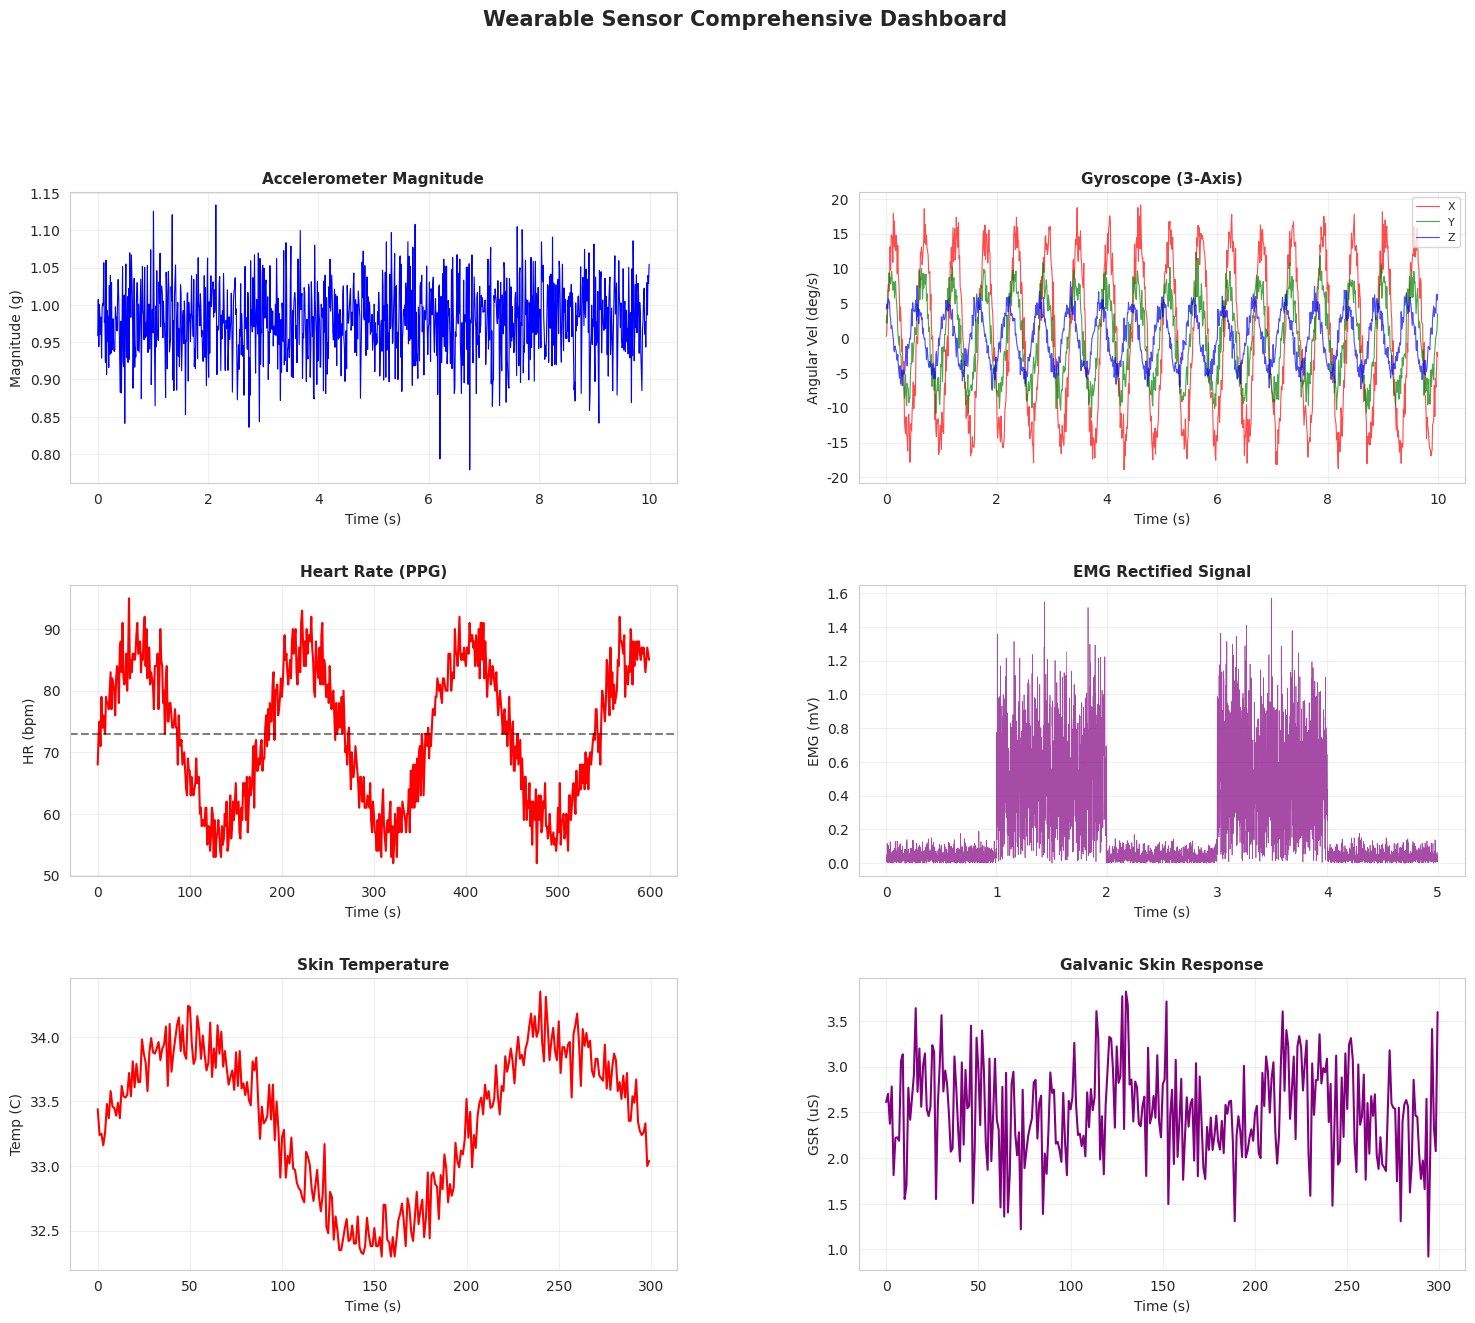

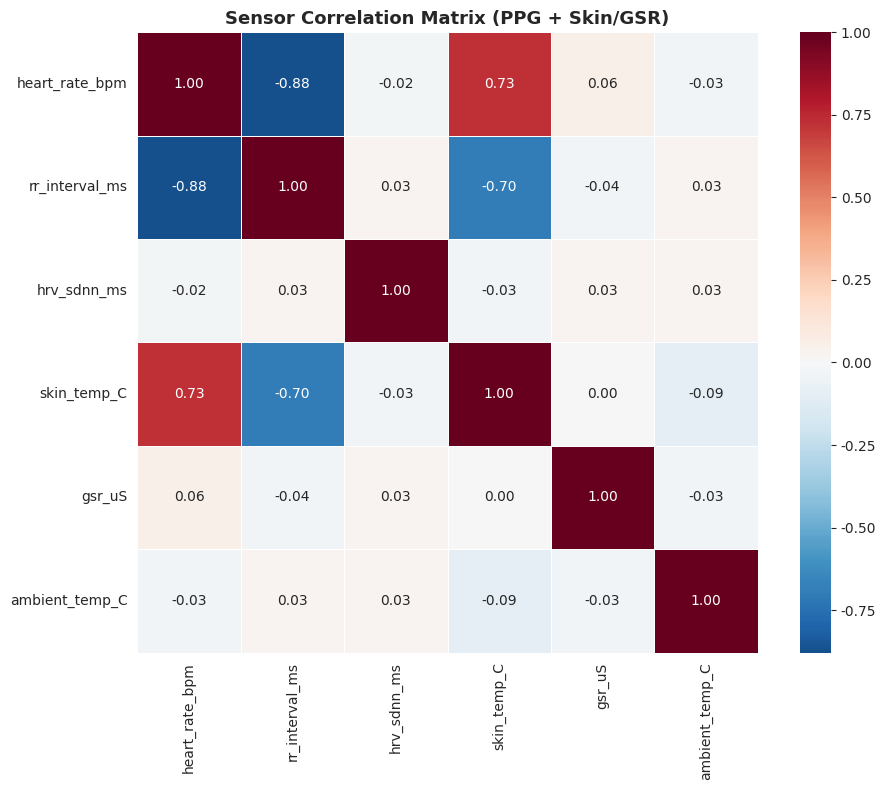

Dashboard & correlation saved


In [8]:
#=== Cell 6: Advanced - Features + Dashboard + Correlation ===

# --- Feature Extraction ---
def extract_features(data, col):
    v = data[col].dropna().values
    return {'sensor': col, 'mean': np.mean(v), 'std': np.std(v), 'rms': np.sqrt(np.mean(v**2)),
            'min': np.min(v), 'max': np.max(v), 'range': np.ptp(v), 'median': np.median(v),
            'skewness': float(pd.Series(v).skew()), 'kurtosis': float(pd.Series(v).kurtosis())}

feat_list = []
for col in ['acc_x_g','acc_y_g','acc_z_g','acc_magnitude_g']: feat_list.append(extract_features(accel_df, col))
for col in ['gyro_x_dps','gyro_y_dps','gyro_z_dps']:         feat_list.append(extract_features(gyro_df, col))
for col in ['heart_rate_bpm','rr_interval_ms','hrv_sdnn_ms']: feat_list.append(extract_features(ppg_df, col))
for col in ['emg_raw_mV','emg_rectified_mV']:                 feat_list.append(extract_features(emg_df, col))
for col in ['skin_temp_C','gsr_uS','ambient_temp_C']:         feat_list.append(extract_features(skin_df, col))

features_df = pd.DataFrame(feat_list).round(4)
features_df.to_csv(f'{run_output_path}/03_extracted_features.csv', index=False)
print('=== Extracted Features ==='); print(features_df.to_string(index=False))

# --- Comprehensive Dashboard (3x2 grid) ---
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(accel_df['timestamp_s'], accel_df['acc_magnitude_g'], 'b-', lw=0.8)
ax1.set_title('Accelerometer Magnitude', fontsize=11, fontweight='bold'); ax1.set_ylabel('Magnitude (g)'); ax1.set_xlabel('Time (s)'); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0,1])
for c, clr, lbl in zip(['gyro_x_dps','gyro_y_dps','gyro_z_dps'], ['r','g','b'], ['X','Y','Z']):
    ax2.plot(gyro_df['timestamp_s'], gyro_df[c], f'{clr}-', alpha=0.7, lw=0.8, label=lbl)
ax2.set_title('Gyroscope (3-Axis)', fontsize=11, fontweight='bold'); ax2.set_ylabel('Angular Vel (deg/s)'); ax2.set_xlabel('Time (s)'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1,0])
ax3.plot(ppg_df['timestamp_s'], ppg_df['heart_rate_bpm'], 'r-', lw=1.5)
ax3.axhline(y=ppg_df['heart_rate_bpm'].mean(), color='k', ls='--', alpha=0.5)
ax3.set_title('Heart Rate (PPG)', fontsize=11, fontweight='bold'); ax3.set_ylabel('HR (bpm)'); ax3.set_xlabel('Time (s)'); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1,1])
ax4.plot(emg_df['timestamp_s'], emg_df['emg_rectified_mV'], 'purple', lw=0.5, alpha=0.7)
ax4.set_title('EMG Rectified Signal', fontsize=11, fontweight='bold'); ax4.set_ylabel('EMG (mV)'); ax4.set_xlabel('Time (s)'); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2,0])
ax5.plot(skin_df['timestamp_s'], skin_df['skin_temp_C'], 'r-', lw=1.5)
ax5.set_title('Skin Temperature', fontsize=11, fontweight='bold'); ax5.set_ylabel('Temp (C)'); ax5.set_xlabel('Time (s)'); ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[2,1])
ax6.plot(skin_df['timestamp_s'], skin_df['gsr_uS'], 'purple', lw=1.5)
ax6.set_title('Galvanic Skin Response', fontsize=11, fontweight='bold'); ax6.set_ylabel('GSR (uS)'); ax6.set_xlabel('Time (s)'); ax6.grid(True, alpha=0.3)

fig.suptitle('Wearable Sensor Comprehensive Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(f'{run_output_path}/03_comprehensive_dashboard.png', dpi=150, bbox_inches='tight'); plt.show()

# --- Correlation Heatmap ---
merged = pd.merge(ppg_df, skin_df, on='timestamp_s', how='inner')
corr_cols = [c for c in ['heart_rate_bpm','rr_interval_ms','hrv_sdnn_ms','skin_temp_C','gsr_uS','ambient_temp_C'] if c in merged.columns]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(merged[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Sensor Correlation Matrix (PPG + Skin/GSR)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{run_output_path}/03_sensor_correlation.png', dpi=150, bbox_inches='tight'); plt.show()
print('Dashboard & correlation saved')

---
## Conclusion

### Week 4 Summary

**Beginner:** 3-axis accelerometer & gyroscope visualization, basic statistics (mean, std, min, max)

**Intermediate:** Butterworth low-pass filter, FFT frequency domain analysis, before/after comparison

**Advanced:** Multi-sensor integration (IMU, PPG, EMG, Skin Temp, GSR), feature extraction, comprehensive dashboard, correlation analysis

### Clinical Applications
- Gait analysis and activity recognition
- Rehabilitation exercise monitoring
- Fall detection and early warning systems
- Autonomic nervous system assessment (HRV + GSR)

### Next Week (Week 5)
Gait Analysis: gait event detection and gait parameter analysis using sensor signals.

In [9]:
#=== Cell 7: Final Summary ===

summary = f"""
========================================
     Week 4 Analysis Complete
========================================
Output: {run_output_path}

1. Beginner
   - 01_accelerometer_raw_signal.png
   - 01_accelerometer_statistics.csv
   - 01_gyroscope_raw_signal.png
   - 01_gyroscope_statistics.csv

2. Intermediate
   - 02_filter_comparison.png
   - 02_frequency_analysis.png
   - 02_accelerometer_filtered.csv
   - 02_gyroscope_filtered.csv

3. Advanced
   - 03_ppg_heart_rate.png
   - 03_emg_muscle_activity.png
   - 03_skin_temp_gsr.png
   - 03_extracted_features.csv
   - 03_comprehensive_dashboard.png
   - 03_sensor_correlation.png
========================================
"""
print(summary)
with open(f'{run_output_path}/SUMMARY.txt', 'w') as f: f.write(summary)
print('Output files:'); [print(f'  {f}') for f in sorted(os.listdir(run_output_path))]


     Week 4 Analysis Complete
Output: /content/drive/MyDrive/4week/output/run_20260416_082859

1. Beginner
   - 01_accelerometer_raw_signal.png
   - 01_accelerometer_statistics.csv
   - 01_gyroscope_raw_signal.png
   - 01_gyroscope_statistics.csv

2. Intermediate
   - 02_filter_comparison.png
   - 02_frequency_analysis.png
   - 02_accelerometer_filtered.csv
   - 02_gyroscope_filtered.csv

3. Advanced
   - 03_ppg_heart_rate.png
   - 03_emg_muscle_activity.png
   - 03_skin_temp_gsr.png
   - 03_extracted_features.csv
   - 03_comprehensive_dashboard.png
   - 03_sensor_correlation.png

Output files:
  01_accelerometer_raw_signal.png
  01_accelerometer_statistics.csv
  01_gyroscope_raw_signal.png
  01_gyroscope_statistics.csv
  02_accelerometer_filtered.csv
  02_filter_comparison.png
  02_frequency_analysis.png
  02_gyroscope_filtered.csv
  03_comprehensive_dashboard.png
  03_emg_muscle_activity.png
  03_extracted_features.csv
  03_ppg_heart_rate.png
  03_sensor_correlation.png
  03_skin_te

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

---
## 분석 결과 전문가 해석 / 分析结果专家解读

### 1. 가속도계 & 자이로스코프 (IMU) / 加速度计与陀螺仪

**가속도계 (加速度计)**
- Y축 평균 약 0.98g → 중력가속도(1g)에 근접하여 센서가 수직 방향으로 올바르게 정렬되어 있음을 확인합니다.
  Y轴平均值约0.98g → 接近重力加速度(1g)，确认传感器垂直方向校准正确。
- X축(0.0016g)과 Z축(-0.0012g)의 평균이 거의 0에 가깝고, 표준편차가 0.05~0.07g 수준 → **정적 상태에서의 미세한 체동(postural sway)**을 반영합니다.
  X轴(0.0016g)和Z轴(-0.0012g)的平均值接近零，标准差为0.05~0.07g → 反映了**静态下的微小姿势摇摆(postural sway)**。
- 가속도 크기 범위(0.78~1.13g)는 일상적 활동 수준이며, 격렬한 운동이나 낙상 이벤트는 포함되지 않았습니다.
  加速度幅值范围(0.78~1.13g)属于日常活动水平，未包含剧烈运动或跌倒事件。
- 왜도(skewness)와 첨도(kurtosis)가 0에 근접 → **정규분포에 가까운 안정적 신호**임을 나타냅니다.
  偏度和峰度接近0 → 表明信号呈**接近正态分布的稳定特征**。

**자이로스코프 (陀螺仪)**
- X축(Roll) 표준편차 10.79°/s > Y축(5.91°/s) > Z축(3.64°/s) → **시상면(sagittal plane) 회전 운동이 가장 활발**하며, 보행 시 발목/무릎 관절의 굴곡-신전 패턴과 일치합니다.
  X轴(Roll)标准差10.79°/s > Y轴(5.91°/s) > Z轴(3.64°/s) → **矢状面旋转运动最为活跃**，与步行时踝/膝关节屈伸模式一致。
- 첨도가 모두 음수(-1.2~-1.4) → **편평 분포(platykurtic)** 특성을 보이며, 각속도가 넓은 범위에 걸쳐 균등하게 분포합니다.
  峰度均为负值(-1.2~-1.4) → 呈**扁平分布(platykurtic)**特征，角速度在较宽范围内均匀分布。

---

### 2. PPG 기반 심박 분석 / 基于PPG的心率分析

- 평균 심박수 **73.0 bpm** → 건강한 성인 안정 시 정상 범위(60~100 bpm) 내.
  平均心率**73.0 bpm** → 处于健康成人静息正常范围(60~100 bpm)内。
- **SDNN = 45.07ms** → 일반적으로 SDNN > 40ms이면 양호한 자율신경 기능을 시사하며, 이 수치는 양호합니다.
  **SDNN = 45.07ms** → 通常SDNN > 40ms提示良好的自主神经功能，该数值属于良好水平。
- RR 간격 범위(645~996ms) → 상당한 심박 변이도(HRV)를 보여주며, **부교감신경(미주신경)의 활발한 조절 작용**을 반영합니다.
  RR间期范围(645~996ms) → 显示显著的心率变异性(HRV)，反映**副交感神经(迷走神经)的活跃调节作用**。
- 심박수의 음의 왜도(-0.12) → 서맥 방향으로 약간 치우침. **안정 시 부교감신경 우세 상태**와 일치합니다.
  心率呈轻微负偏(-0.12) → 略向心动过缓方向偏移，与**静息时副交感神经占优状态**一致。

---

### 3. EMG (근전도) 분석 / 肌电图(EMG)分析

- Raw EMG 평균(0.198mV)과 정류 EMG 평균(0.228mV)의 차이는 신호 처리(정류)의 효과를 보여줍니다.
  原始EMG平均值(0.198mV)与整流EMG平均值(0.228mV)的差异体现了信号处理(整流)的效果。
- 양의 왜도(1.21~1.44) → **간헐적 근수축(burst) 패턴**으로, 대부분 근이완 상태에서 간간이 수축이 발생하는 전형적 일상 활동 패턴입니다.
  正偏度(1.21~1.44) → 呈**间歇性肌肉收缩(burst)模式**，大部分时间处于肌肉松弛状态，偶有收缩，是典型的日常活动模式。
- 정류 EMG 최대값(1.57mV) → 저~중강도 근활성도. **최대 수의 수축(MVC)** 대비 낮은 수준으로 피로도가 낮은 상태입니다.
  整流EMG最大值(1.57mV) → 低至中等强度肌肉活动。相对于**最大自主收缩(MVC)**处于较低水平，提示疲劳度较低。

---

### 4. 피부 온도 & GSR / 皮肤温度与GSR(皮肤电反应)

- **피부 온도(皮肤温度)** 평균 33.37°C → 말초 체온 정상 범위(32~36°C). 2.05°C 범위는 혈관 수축/이완에 의한 자연스러운 변동입니다.
  平均33.37°C → 处于末梢体温正常范围(32~36°C)。2.05°C的范围反映了血管收缩/舒张引起的自然变动。
- 온도의 음의 왜도(-0.45) → 측정 기간 동안 **점진적 냉각 경향(말초 혈관 수축)**이 있었습니다.
  温度呈负偏(-0.45) → 测量期间存在**渐进性降温趋势(末梢血管收缩)**。
- **GSR(皮肤电)** 평균 2.51μS, 표준편차 0.52μS → **교감신경 활성도의 중등도 변동**을 나타냅니다.
  平均2.51μS，标准差0.52μS → 表明**交感神经活动的中等程度波动**。
- 왜도/첨도 ≈ 0 → 급격한 스트레스 반응(phasic response)보다 **안정적 기저 피부 전도도(tonic level)**가 우세합니다.
  偏度/峰度≈0 → 相比急性应激反应(phasic response)，**稳定的基础皮肤电导(tonic level)**占主导。

---

### 5. 통합 해석 / 综合解读

전체 데이터를 종합하면, 피험자는 **안정 시 또는 경미한 활동 상태**에 있었던 것으로 판단됩니다.
综合全部数据，判断受试者处于**静息或轻度活动状态**。

| 근거 / 依据 | 한국어 설명 | 中文说明 |
|------------|-----------|--------|
| 자율신경 균형 | 양호한 HRV(SDNN ~45ms)와 안정적 GSR → 교감-부교감 신경 균형 유지 | 良好的HRV(SDNN ~45ms)和稳定的GSR → 交感-副交感神经平衡 |
| 운동 강도 | 가속도계 낮은 변동성 + EMG 간헐적 활성 → 저강도 일상 활동 | 加速度计低变异性 + EMG间歇性活动 → 低强度日常活动 |
| 체온 조절 | 안정적 피부 온도 → 항상성 유지 양호 | 稳定的皮肤温度 → 体内稳态维持良好 |

**임상적 시사점 / 临床意义:**
이러한 멀티센서 통합 분석은 재활 환자의 일상 활동 모니터링, 만성질환자의 자율신경 기능 평가, 노인의 낙상 위험 조기 감지에 직접 적용 가능합니다. 특히 IMU+PPG+GSR 조합은 **스트레스-활동-생리반응의 삼각 검증(triangulation)**을 가능하게 합니다.
该多传感器综合分析可直接应用于康复患者日常活动监测、慢性病患者自主神经功能评估、以及老年人跌倒风险早期预警。IMU+PPG+GSR的组合实现了**压力-活动-生理反应的三角验证(triangulation)**。

---
## 환자 피드백 보고서 / 患者反馈报告

> 웨어러블 센서 분석 결과를 바탕으로 환자에게 전달할 수 있는 **임상 피드백 예시**입니다.
> 以下是基于可穿戴传感器分析结果，可向患者传达的**临床反馈示例**。
> 실제 임상에서는 담당 의료진의 판단 하에 개인화하여 사용합니다. / 实际临床中应由主治医疗团队个性化使用。

---

### 1. 심장 건강 / 心脏健康

| 항목/项目 | 측정값/测量值 | 정상 범위/正常范围 | 판정/判定 |
|----------|------------|-----------------|----------|
| 평균 심박수 / 平均心率 | 73.0 bpm | 60~100 bpm | ✅ 정상/正常 |
| 심박 변이도 / 心率变异性 (SDNN) | 45.1 ms | > 40 ms | ✅ 양호/良好 |
| RR 간격 범위 / RR间期范围 | 645~996 ms | — | ✅ 적절/适当 |

**피드백 / 反馈:**
귀하의 안정 시 심박수는 **73회/분**으로 정상 범위이며, 심박 변이도(HRV)가 양호하여 자율신경계가 잘 작동하고 있습니다. 심장이 외부 자극에 유연하게 반응할 수 있는 상태입니다.
您的静息心率为**73次/分钟**，处于正常范围。心率变异性(HRV)良好，表明自主神经系统运作正常，心脏能够灵活应对外部刺激。

**생활 권고 / 生活建议:** 규칙적인 유산소 운동(주 3~5회, 30분 이상)을 권장합니다.
建议进行规律的有氧运动（每周3~5次，每次30分钟以上）。

---

### 2. 신체 활동 & 균형 / 身体活动与平衡

| 항목/项목 | 측정값/测量值 | 의미/含义 |
|----------|------------|----------|
| 가속도 변동 / 加速度变动 | 0.78~1.13g | 저강도 일상 활동 / 低强度日常活动 |
| 주요 움직임 / 主要运动方向 | Roll축 우세 | 보행 패턴 일치 / 与步行模式一致 |
| 근활성도 / 肌肉活动度 (EMG) | 평균 0.23 mV | 저강도 근수축 / 低强度肌肉收缩 |

**피드백 / 反馈:**
측정 기간 동안 활동량은 **가벼운 일상 활동 수준**이었습니다. 급격한 움직임이나 낙상 위험 신호는 관찰되지 않았으며, 근육 활동은 간헐적 수축으로 일상적 동작(걷기, 앉기 등)과 일치합니다.
测量期间的活动量为**轻度日常活动水平**。未观察到剧烈运动或跌倒风险信号，肌肉活动呈间歇性收缩，与日常动作（走路、坐下等）一致。

**생활 권고 / 生活建议:**
- 하루 30분 이상의 걷기 운동으로 활동량을 점차 늘려보세요.
  每天步行30分钟以上，逐步增加活动量。
- 주 2회 이상 가벼운 저항 운동(스쿼트, 밴드 운동 등)을 추천합니다.
  建议每周至少2次轻度阻力训练（深蹲、弹力带等）。

---

### 3. 스트레스 & 자율신경 / 压力与自主神经状态

| 항목/项목 | 측정값/测量值 | 의미/含义 |
|----------|------------|----------|
| 피부 전도도 / 皮肤电导 (GSR) | 평균 2.51 μS | 안정적 / 稳定 |
| 피부 온도 / 皮肤温度 | 평균 33.4°C | 정상 범위 / 正常范围 |
| GSR 변동 / GSR波动 | SD 0.52 μS | 급성 스트레스 없음 / 无急性应激 |

**피드백 / 反馈:**
피부 전도도와 체온 데이터를 종합하면, 측정 기간 동안 **스트레스 수준이 낮은 상태**였습니다. 급격한 교감신경 흥분(긴장, 불안 등)은 관찰되지 않았으며, 자율신경의 균형이 잘 유지되고 있습니다.
综合皮肤电导和体温数据，测量期间**压力水平较低**。未观察到急性交感神经兴奋（紧张、焦虑等），自主神经平衡维持良好。

**생활 권고 / 生활建議:** 충분한 수면(7~8시간)과 스트레스 관리(심호흡, 명상 등)를 지속하세요.
保持充足睡眠（7~8小时）并持续进行压力管理（深呼吸、冥想等）。

---

### 4. 종합 평가 / 综合评估

```
╔════════════════════════════════════════════════════════════╗
║        종합 건강 상태 요약 / 综合健康状态摘要                ║
╠════════════════════════════════════════════════════════════╣
║  심장 건강 / 心脏健康     ████████████████████  ✅ 양호/良好  ║
║  신체 활동 / 身体活动     ██████████░░░░░░░░░░  ⚠️ 보통/一般 ║
║  근력 상태 / 肌力状态     ████████████░░░░░░░░  ⚠️ 보통/一般 ║
║  스트레스 / 压力水平      ████████████████████  ✅ 낮음/低   ║
║  자율신경 / 自主神经      ████████████████████  ✅ 양호/良好  ║
╚════════════════════════════════════════════════════════════╝
```

**종합 소견 / 综合意见:**
심혈관 기능과 자율신경 균형은 **양호한 상태**입니다. 다만 신체 활동량이 다소 낮으므로 점진적으로 활동량을 늘리는 것을 권장합니다. 근력 강화 운동을 병행하면 전반적인 건강 지표 개선에 도움이 됩니다.
心血管功能和自主神经平衡处于**良好状态**。但身体活动量偏低，建议逐步增加活动量。配合肌力强化训练将有助于整体健康指标的改善。

---

### 5. 다음 검사 권고 / 后续检查建议

| 권고 항목 / 建议项目 | 시기 / 时间 | 목적 / 目的 |
|-------------------|-----------|------------|
| 웨어러블 재측정 / 可穿戴设备复测 | 4주 후 / 4周后 | 활동량 변화 추적 / 追踪活动量变化 |
| 24시간 HRV 모니터링 / 24小时HRV监测 | 필요 시 / 需要时 | 자율신경 정밀 평가 / 自主神经精密评估 |
| 체력 검사 (6분 보행) / 体能检查(6分钟步行) | 3개월 후 / 3个月后 | 심폐 기능 추적 / 心肺功能追踪 |

> ⚠️ **주의 / 注意:** 본 피드백은 웨어러블 센서 데이터에 기반한 참고 자료이며, 의학적 진단을 대체하지 않습니다. 이상 증상 시 반드시 담당 의료진과 상담하시기 바랍니다.
> 本反馈仅为基于可穿戴传感器数据的参考资料，不替代医学诊断。如有异常症状，请务必咨询主治医疗团队。

---
*본 보고서는 Week 4 웨어러블 센서 분석 실습의 일환으로 생성되었습니다.*
*本报告作为第4周可穿戴传感器分析实习的一部分生成。*

---
## Algorithm Pipeline / 알고리즘 파이프라인 / 算法流程图

아래 코드를 실행하면 원시 센서 데이터 입력부터 환자 피드백 생성까지의 전체 분석 파이프라인 플로우차트가 생성됩니다.
运行以下代码，将生成从原始传感器数据输入到患者反馈生成的完整分析流程图。

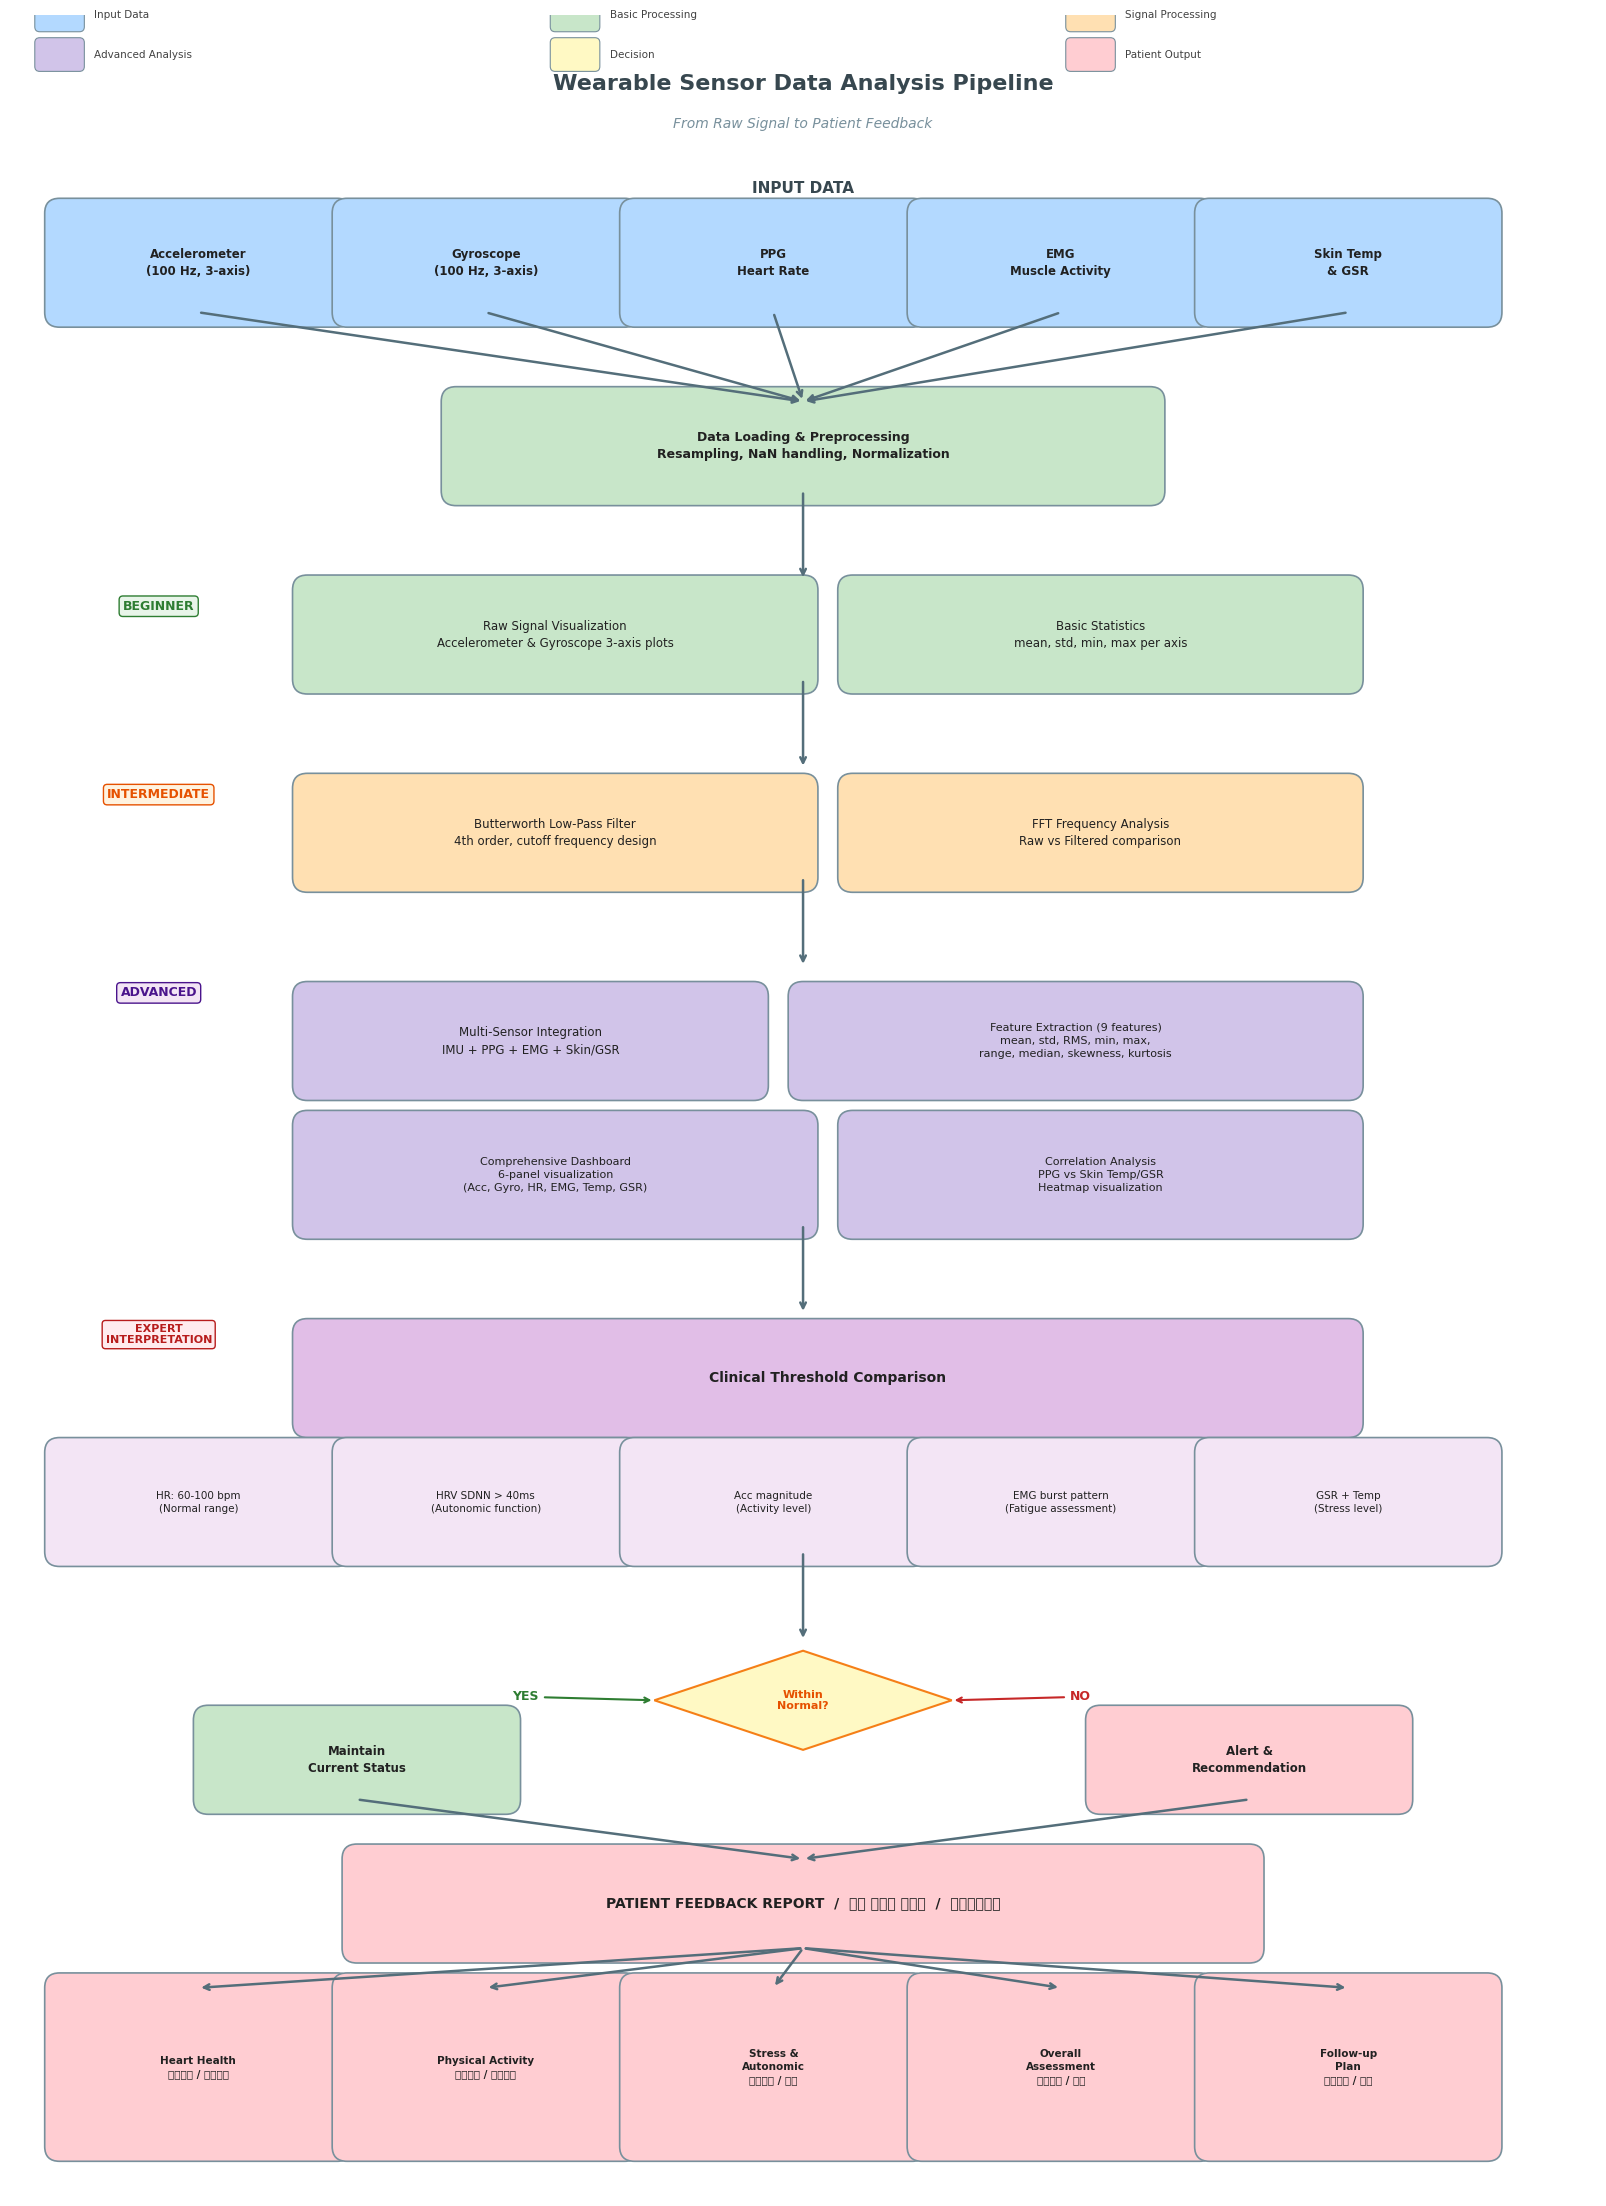


Algorithm pipeline saved: /content/drive/MyDrive/4week/output/run_20260416_082859/algorithm_pipeline.png


In [10]:
#=== Algorithm Pipeline Flowchart Generator ===
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import os

fig, ax = plt.subplots(1, 1, figsize=(16, 22))
ax.set_xlim(0, 16)
ax.set_ylim(0, 22)
ax.axis('off')
fig.patch.set_facecolor('white')

# --- Color scheme ---
C_INPUT   = '#B3D9FF'  # Light blue
C_PROC    = '#C8E6C9'  # Light green
C_FEAT    = '#FFE0B2'  # Light orange
C_INTERP  = '#D1C4E9'  # Light purple
C_FEED    = '#FFCDD2'  # Light pink
C_TITLE   = '#37474F'  # Dark gray
C_ARROW   = '#546E7A'  # Gray

def draw_box(ax, x, y, w, h, text, color, fontsize=9, bold=False, text_color='#212121'):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                         facecolor=color, edgecolor='#78909C', linewidth=1.2)
    ax.add_patch(box)
    weight = 'bold' if bold else 'normal'
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight=weight, color=text_color,
            wrap=True, linespacing=1.4)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=C_ARROW,
                                lw=1.8, connectionstyle='arc3,rad=0'))

# ========== TITLE ==========
ax.text(8, 21.3, 'Wearable Sensor Data Analysis Pipeline',
        ha='center', va='center', fontsize=16, fontweight='bold', color=C_TITLE)
ax.text(8, 20.9, 'From Raw Signal to Patient Feedback',
        ha='center', va='center', fontsize=10, fontstyle='italic', color='#78909C')

# ========== ROW 1: INPUT DATA (y=19.2) ==========
ax.text(8, 20.2, 'INPUT DATA', ha='center', fontsize=11, fontweight='bold', color=C_TITLE)
inputs = ['Accelerometer\n(100 Hz, 3-axis)', 'Gyroscope\n(100 Hz, 3-axis)',
          'PPG\nHeart Rate', 'EMG\nMuscle Activity', 'Skin Temp\n& GSR']
positions_x = [0.5, 3.4, 6.3, 9.2, 12.1]
for i, (txt, px) in enumerate(zip(inputs, positions_x)):
    draw_box(ax, px, 19.0, 2.8, 1.0, txt, C_INPUT, fontsize=8.5, bold=True)

# Arrows from inputs to preprocessing
for px in positions_x:
    draw_arrow(ax, px + 1.4, 19.0, 8.0, 18.1)

# ========== ROW 2: PREPROCESSING (y=17.2) ==========
draw_box(ax, 4.5, 17.2, 7.0, 0.9, 'Data Loading & Preprocessing\nResampling, NaN handling, Normalization',
         C_PROC, fontsize=9, bold=True)
draw_arrow(ax, 8.0, 17.2, 8.0, 16.3)

# ========== ROW 3: BEGINNER (y=15.2) ==========
ax.text(1.5, 16.0, 'BEGINNER', ha='center', fontsize=9, fontweight='bold',
        color='#2E7D32', rotation=0,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor='#2E7D32'))
draw_box(ax, 3.0, 15.3, 5.0, 0.9,
         'Raw Signal Visualization\nAccelerometer & Gyroscope 3-axis plots',
         C_PROC, fontsize=8.5)
draw_box(ax, 8.5, 15.3, 5.0, 0.9,
         'Basic Statistics\nmean, std, min, max per axis',
         C_PROC, fontsize=8.5)
draw_arrow(ax, 8.0, 15.3, 8.0, 14.4)

# ========== ROW 4: INTERMEDIATE (y=13.2) ==========
ax.text(1.5, 14.1, 'INTERMEDIATE', ha='center', fontsize=9, fontweight='bold',
        color='#E65100', rotation=0,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='#E65100'))
draw_box(ax, 3.0, 13.3, 5.0, 0.9,
         'Butterworth Low-Pass Filter\n4th order, cutoff frequency design',
         C_FEAT, fontsize=8.5)
draw_box(ax, 8.5, 13.3, 5.0, 0.9,
         'FFT Frequency Analysis\nRaw vs Filtered comparison',
         C_FEAT, fontsize=8.5)
draw_arrow(ax, 8.0, 13.3, 8.0, 12.4)

# ========== ROW 5: ADVANCED (y=10.5) ==========
ax.text(1.5, 12.1, 'ADVANCED', ha='center', fontsize=9, fontweight='bold',
        color='#4A148C', rotation=0,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F3E5F5', edgecolor='#4A148C'))

draw_box(ax, 3.0, 11.2, 4.5, 0.9,
         'Multi-Sensor Integration\nIMU + PPG + EMG + Skin/GSR',
         C_INTERP, fontsize=8.5)
draw_box(ax, 8.0, 11.2, 5.5, 0.9,
         'Feature Extraction (9 features)\nmean, std, RMS, min, max,\nrange, median, skewness, kurtosis',
         C_INTERP, fontsize=8)

draw_box(ax, 3.0, 9.8, 5.0, 1.0,
         'Comprehensive Dashboard\n6-panel visualization\n(Acc, Gyro, HR, EMG, Temp, GSR)',
         C_INTERP, fontsize=8)
draw_box(ax, 8.5, 9.8, 5.0, 1.0,
         'Correlation Analysis\nPPG vs Skin Temp/GSR\nHeatmap visualization',
         C_INTERP, fontsize=8)
draw_arrow(ax, 8.0, 9.8, 8.0, 8.9)

# ========== ROW 6: EXPERT INTERPRETATION (y=7.5) ==========
ax.text(1.5, 8.6, 'EXPERT\nINTERPRETATION', ha='center', fontsize=8, fontweight='bold',
        color='#B71C1C', rotation=0,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#B71C1C'))

draw_box(ax, 3.0, 7.8, 10.5, 0.9,
         'Clinical Threshold Comparison',
         '#E1BEE7', fontsize=10, bold=True)

thresholds = [
    'HR: 60-100 bpm\n(Normal range)',
    'HRV SDNN > 40ms\n(Autonomic function)',
    'Acc magnitude\n(Activity level)',
    'EMG burst pattern\n(Fatigue assessment)',
    'GSR + Temp\n(Stress level)'
]
th_x = [0.5, 3.4, 6.3, 9.2, 12.1]
for txt, px in zip(thresholds, th_x):
    draw_box(ax, px, 6.5, 2.8, 1.0, txt, '#F3E5F5', fontsize=7.5)

draw_arrow(ax, 8.0, 6.5, 8.0, 5.6)

# ========== ROW 7: DECISION (y=4.8) ==========
# Diamond shape for decision
diamond_x = [6.5, 8.0, 9.5, 8.0, 6.5]
diamond_y = [5.0, 5.5, 5.0, 4.5, 5.0]
from matplotlib.patches import Polygon
diamond = Polygon(list(zip(diamond_x, diamond_y)), closed=True,
                  facecolor='#FFF9C4', edgecolor='#F57F17', linewidth=1.5)
ax.add_patch(diamond)
ax.text(8.0, 5.0, 'Within\nNormal?', ha='center', va='center',
        fontsize=8, fontweight='bold', color='#E65100')

# YES / NO branches
ax.annotate('YES', xy=(6.5, 5.0), xytext=(5.2, 5.0),
            fontsize=9, fontweight='bold', color='#2E7D32', ha='center',
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1.5))
ax.annotate('NO', xy=(9.5, 5.0), xytext=(10.8, 5.0),
            fontsize=9, fontweight='bold', color='#C62828', ha='center',
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5))

draw_box(ax, 2.0, 4.0, 3.0, 0.8, 'Maintain\nCurrent Status', '#C8E6C9', fontsize=8.5, bold=True)
draw_box(ax, 11.0, 4.0, 3.0, 0.8, 'Alert &\nRecommendation', '#FFCDD2', fontsize=8.5, bold=True)

# Arrows to patient feedback
draw_arrow(ax, 3.5, 4.0, 8.0, 3.4)
draw_arrow(ax, 12.5, 4.0, 8.0, 3.4)

# ========== ROW 8: PATIENT FEEDBACK (y=1.5) ==========
draw_box(ax, 3.5, 2.5, 9.0, 0.9,
         'PATIENT FEEDBACK REPORT  /  환자 피드백 보고서  /  患者反馈报告',
         C_FEED, fontsize=10, bold=True)

categories = [
    'Heart Health\n심장건강 / 心脏健康',
    'Physical Activity\n신체활동 / 身体活动',
    'Stress &\nAutonomic\n스트레스 / 压力',
    'Overall\nAssessment\n종합평가 / 综合',
    'Follow-up\nPlan\n추적계획 / 随访'
]
cat_x = [0.5, 3.4, 6.3, 9.2, 12.1]
for txt, px in zip(categories, cat_x):
    draw_box(ax, px, 0.5, 2.8, 1.6, txt, C_FEED, fontsize=7.5, bold=True)

for px in cat_x:
    draw_arrow(ax, 8.0, 2.5, px + 1.4, 2.1)

# ========== LEGEND ==========
legend_items = [
    (C_INPUT, 'Input Data'), (C_PROC, 'Basic Processing'),
    (C_FEAT, 'Signal Processing'), (C_INTERP, 'Advanced Analysis'),
    ('#FFF9C4', 'Decision'), (C_FEED, 'Patient Output')
]
for i, (color, label) in enumerate(legend_items):
    lx = 0.3 + (i % 3) * 5.2
    ly = 22.0 if i < 3 else 21.6
    ax.add_patch(FancyBboxPatch((lx, ly - 0.12), 0.4, 0.24,
                                boxstyle="round,pad=0.05",
                                facecolor=color, edgecolor='#78909C', linewidth=0.8))
    ax.text(lx + 0.55, ly, label, fontsize=7.5, va='center', color='#424242')

plt.tight_layout(pad=0.5)
save_path = f'{run_output_path}/algorithm_pipeline.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'\nAlgorithm pipeline saved: {save_path}')

In [11]:
#=== Copy Algorithm Pipeline PPT to Output ===
import shutil, os

base_path = '/content/drive/MyDrive/4week'
pptx_src = os.path.join(base_path, 'algorithm_pipeline_A3.pptx')
pptx_dst = os.path.join(run_output_path, 'algorithm_pipeline_A3.pptx')

if os.path.exists(pptx_src):
    shutil.copy2(pptx_src, pptx_dst)
    print(f'PPT copied to: {pptx_dst}')
else:
    print(f'Source PPT not found: {pptx_src}')
    print('Please ensure algorithm_pipeline_A3.pptx is in the 4week folder.')

print(f'\n=== All Output Files ===')
print(f'Location: {run_output_path}')
for f in sorted(os.listdir(run_output_path)):
    size = os.path.getsize(os.path.join(run_output_path, f))
    print(f'  {f} ({size:,} bytes)')

Source PPT not found: /content/drive/MyDrive/4week/algorithm_pipeline_A3.pptx
Please ensure algorithm_pipeline_A3.pptx is in the 4week folder.

=== All Output Files ===
Location: /content/drive/MyDrive/4week/output/run_20260416_082859
  01_accelerometer_raw_signal.png (598,753 bytes)
  01_accelerometer_statistics.csv (248 bytes)
  01_gyroscope_raw_signal.png (352,528 bytes)
  01_gyroscope_statistics.csv (217 bytes)
  02_accelerometer_filtered.csv (94,764 bytes)
  02_filter_comparison.png (738,742 bytes)
  02_frequency_analysis.png (230,669 bytes)
  02_gyroscope_filtered.csv (78,525 bytes)
  03_comprehensive_dashboard.png (551,898 bytes)
  03_emg_muscle_activity.png (259,171 bytes)
  03_extracted_features.csv (1,160 bytes)
  03_ppg_heart_rate.png (389,926 bytes)
  03_sensor_correlation.png (101,359 bytes)
  03_skin_temp_gsr.png (359,796 bytes)
  SUMMARY.txt (711 bytes)
  algorithm_pipeline.png (804,436 bytes)
